In [21]:
import pandas as pd

contacts = pd.read_csv("C:/Users/Ilaya/Downloads/data/contacts.csv")
opportunities = pd.read_csv("C:/Users/Ilaya/Downloads/data/opportunities.csv")
campaigns = pd.read_csv("C:/Users/Ilaya/Downloads/data/campaigns.csv")



# CLEAN COLUMN NAMES

contacts.columns = (
    contacts.columns
    .str.lower()
    .str.replace(" ", "_"))

opportunities.columns = (
    opportunities.columns
    .str.lower()
    .str.replace(" ", "_"))

campaigns.columns = (
    campaigns.columns
    .str.lower()
    .str.replace(" ", "_"))

# CHECK DATA

print("CONTACTS COLUMNS:")
print(contacts.columns.tolist())

print("\nOPPORTUNITIES COLUMNS:")
print(opportunities.columns.tolist())

print("\nCAMPAIGNS COLUMNS:")
print(campaigns.columns.tolist())

# REMOVE USELESS COLUMNS

opportunities = opportunities.drop(columns=[
    'lost_reason_id',
    'lost_reason_name',
    'how_old_is_your_current_roof?',
    'what_service_do_you_need?',
    'roof_freeinspection_higherintent_sms_v1',
    'what_type_of_property_do_you_own?',
    'forecast_slippage_(days)',
    'forecast_slippage_count',
    'forecast_probability',
    'expected_close_date'
], errors='ignore')

# CLEAN STATUS COLUMN

opportunities['status'] = (
    opportunities['status']
    .astype(str)
    .str.strip()
    .str.lower())

# DATA OVERVIEW

print("\n=========================")
print("DATASET SIZES")
print("=========================")

print("Contacts:", len(contacts))
print("Opportunities:", len(opportunities))
print("Campaigns:", len(campaigns))

# DUPLICATES

print("\n=========================")
print("DUPLICATES")
print("=========================")

print("Contacts duplicates:", contacts.duplicated().sum())
print("Opportunities duplicates:", opportunities.duplicated().sum())
print("Campaigns duplicates:", campaigns.duplicated().sum())

# MISSING VALUES

print("\n=========================")
print("MISSING VALUES - OPPORTUNITIES")
print("=========================")

print(
    opportunities.isnull()
    .sum()
    .sort_values(ascending=False)
    .head(15))

# STATUS ANALYSIS

print("\n=========================")
print("STATUS COUNTS")
print("=========================")

print(
    opportunities['status']
    .value_counts(dropna=False)
)

# PIPELINE ANALYSIS

print("\n=========================")
print("PIPELINE COUNTS")
print("=========================")

print(
    opportunities['pipeline']
    .value_counts()
)


# STAGE ANALYSIS

print("\n=========================")
print("STAGE COUNTS")
print("=========================")

print(
    opportunities['stage']
    .value_counts()
)


# CAMPAIGN KPIs

print("\n=========================")
print("CAMPAIGN KPIs")
print("=========================")

total_spend = campaigns['amount_spent_(usd)'].sum()
total_results = campaigns['results'].sum()

print("Total Ad Spend:", total_spend)
print("Total Results:", total_results)


# LEAD VALUE ANALYSIS

print("\n=========================")
print("LEAD VALUE ANALYSIS")
print("=========================")

print("Total Opportunities:", len(opportunities))

print(
    "Total Lead Value:",
    opportunities['lead_value'].sum()
)

CONTACTS COLUMNS:
['contact_id', 'first_name', 'last_name', 'phone', 'email', 'business_name', 'created', 'last_activity', 'tags']

OPPORTUNITIES COLUMNS:
['opportunity_name', 'contact_name', 'phone', 'email', 'pipeline', 'stage', 'lead_value', 'source', 'assigned', 'created_on', 'updated_on', 'lost_reason_id', 'lost_reason_name', 'followers', 'notes', 'tags', 'engagement_score', 'status', 'expected_close_date', 'forecast_probability', 'forecast_slippage_count', 'forecast_slippage_(days)', 'what_type_of_property_do_you_own?', 'roof_freeinspection_higherintent_sms_v1', 'what_service_do_you_need?', 'how_old_is_your_current_roof?', 'meta_purchase_value', 'opportunity_id', 'contact_id', 'pipeline_stage_id', 'pipeline_id', 'days_since_last_stage_change_', 'days_since_last_status_change_', 'days_since_last_update_']

CAMPAIGNS COLUMNS:
['reporting_starts', 'reporting_ends', 'campaign_name', 'campaign_delivery', 'attribution_setting', 'results', 'result_indicator', 'reach', 'frequency', 'cost

In [22]:
# BUSINESS KPIs

total_contacts = len(contacts)
total_opportunities = len(opportunities)
total_campaigns = len(campaigns)

total_spend = campaigns['amount_spent_(usd)'].sum()
total_results = campaigns['results'].sum()
total_lead_value = opportunities['lead_value'].sum()

cost_per_result = total_spend / total_results
opportunity_rate = total_opportunities / total_contacts
estimated_roas = total_lead_value / total_spend

print("Total Contacts:", total_contacts)
print("Total Opportunities:", total_opportunities)
print("Total Campaigns:", total_campaigns)
print("Total Ad Spend:", round(total_spend, 2))
print("Total Results:", total_results)
print("Cost Per Result:", round(cost_per_result, 2))
print("Opportunity Rate:", round(opportunity_rate * 100, 2), "%")
print("Total Lead Value:", round(total_lead_value, 2))
print("Estimated ROAS:", round(estimated_roas, 2))

Total Contacts: 1277
Total Opportunities: 192
Total Campaigns: 18
Total Ad Spend: 22019.11
Total Results: 327.0
Cost Per Result: 67.34
Opportunity Rate: 15.04 %
Total Lead Value: 231900
Estimated ROAS: 10.53


In [ ]:
# CAMPAIGN PERFORMANCE TABLE
campaign_performance = campaigns[[
    'campaign_name',
    'amount_spent_(usd)',
    'results',
    'cost_per_results',
    'reach',
    'impressions',
    'link_clicks',
    'landing_page_views'
]]

campaign_performance = campaign_performance.sort_values(
    by='amount_spent_(usd)',
    ascending=False
)

campaign_performance.head(10)

,campaign_name,amount_spent_(usd),results,cost_per_results,reach,impressions,link_clicks,landing_page_views
2,New Leads Campaign kitchens - Copy 2,11062.60,177.0,62.500565,79531,178804,1929.0,3.0
8,New Leads Campaign impact windows,9974.48,139.0,71.758849,91121,139427,2791.0,3.0
17,New Roofing Campaign - Copy,982.03,11.0,89.275455,7565,12215,261.0,NaN
0,All Services Launch,0.00,NaN,NaN,0,0,NaN,NaN
1,New Leads Campaign Bathrooms,0.00,NaN,NaN,0,0,NaN,NaN
4,New Leads Campaign Roofs 1,0.00,NaN,NaN,0,0,NaN,NaN
5,New Leads Campaign paint - Copy,0.00,NaN,NaN,0,0,NaN,NaN
6,New Leads Campaign Roofs,0.00,NaN,NaN,0,0,NaN,NaN
7,‏‎New Leads Campaign Roofs‎‏ - 2,0.00,NaN,NaN,0,0,NaN,NaN
3,New Leads Campaign paint,0.00,NaN,NaN,0,0,NaN,NaN


In [24]:
# =========================
# CAMPAIGN PERFORMANCE TABLE
# =========================

campaign_performance = campaigns[[
    'campaign_name',
    'amount_spent_(usd)',
    'results',
    'cost_per_results',
    'reach',
    'impressions',
    'link_clicks',
    'landing_page_views'
]].copy()

campaign_performance = campaign_performance.sort_values(
    by='amount_spent_(usd)',
    ascending=False
)

campaign_performance.head(10)

,campaign_name,amount_spent_(usd),results,cost_per_results,reach,impressions,link_clicks,landing_page_views
2,New Leads Campaign kitchens - Copy 2,11062.60,177.0,62.500565,79531,178804,1929.0,3.0
8,New Leads Campaign impact windows,9974.48,139.0,71.758849,91121,139427,2791.0,3.0
17,New Roofing Campaign - Copy,982.03,11.0,89.275455,7565,12215,261.0,NaN
0,All Services Launch,0.00,NaN,NaN,0,0,NaN,NaN
1,New Leads Campaign Bathrooms,0.00,NaN,NaN,0,0,NaN,NaN
4,New Leads Campaign Roofs 1,0.00,NaN,NaN,0,0,NaN,NaN
5,New Leads Campaign paint - Copy,0.00,NaN,NaN,0,0,NaN,NaN
6,New Leads Campaign Roofs,0.00,NaN,NaN,0,0,NaN,NaN
7,‏‎New Leads Campaign Roofs‎‏ - 2,0.00,NaN,NaN,0,0,NaN,NaN
3,New Leads Campaign paint,0.00,NaN,NaN,0,0,NaN,NaN


In [27]:
# CAMPAIGN PERFORMANCE TABLE

campaign_performance = campaigns[[
    'campaign_name',
    'amount_spent_(usd)',
    'results',
    'cost_per_results',
    'reach',
    'impressions',
    'link_clicks',
    'landing_page_views'
]].copy()

campaign_performance = campaign_performance.sort_values(
    by='amount_spent_(usd)',
    ascending=False
)

campaign_performance.head(10)

,campaign_name,amount_spent_(usd),results,cost_per_results,reach,impressions,link_clicks,landing_page_views
2,New Leads Campaign kitchens - Copy 2,11062.60,177.0,62.500565,79531,178804,1929.0,3.0
8,New Leads Campaign impact windows,9974.48,139.0,71.758849,91121,139427,2791.0,3.0
17,New Roofing Campaign - Copy,982.03,11.0,89.275455,7565,12215,261.0,NaN
0,All Services Launch,0.00,NaN,NaN,0,0,NaN,NaN
1,New Leads Campaign Bathrooms,0.00,NaN,NaN,0,0,NaN,NaN
4,New Leads Campaign Roofs 1,0.00,NaN,NaN,0,0,NaN,NaN
5,New Leads Campaign paint - Copy,0.00,NaN,NaN,0,0,NaN,NaN
6,New Leads Campaign Roofs,0.00,NaN,NaN,0,0,NaN,NaN
7,‏‎New Leads Campaign Roofs‎‏ - 2,0.00,NaN,NaN,0,0,NaN,NaN
3,New Leads Campaign paint,0.00,NaN,NaN,0,0,NaN,NaN


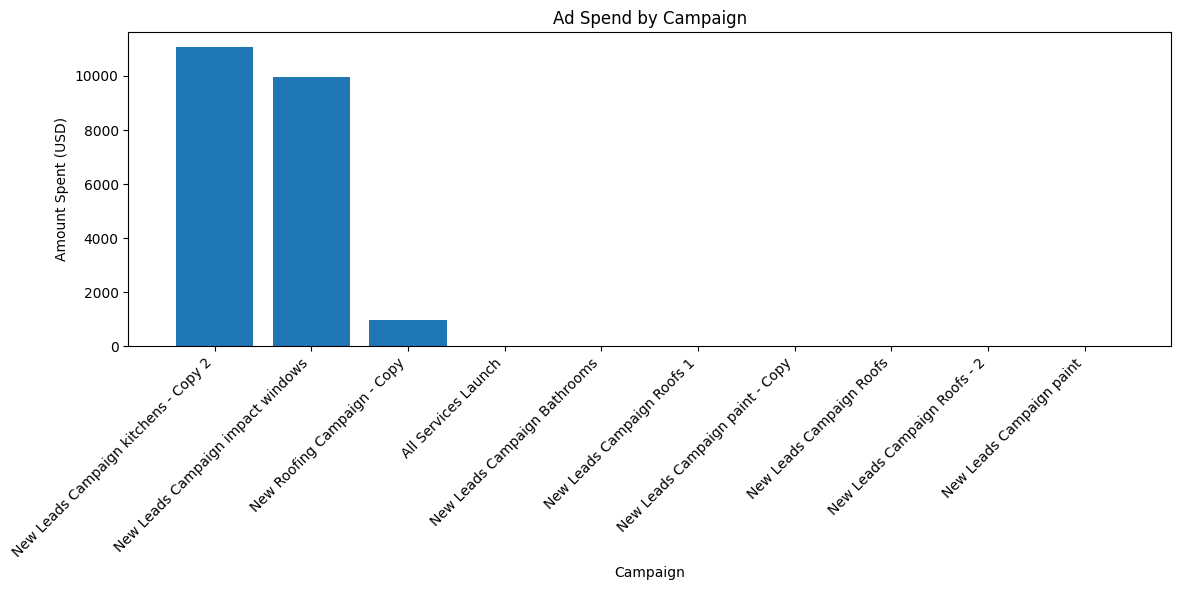

In [47]:
import matplotlib.pyplot as plt

# SPEND BY CAMPAIGN

top_campaigns = campaign_performance.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_campaigns['campaign_name'],
    top_campaigns['amount_spent_(usd)']
)

plt.xticks(rotation=45, ha='right')

plt.title("Ad Spend by Campaign")
plt.xlabel("Campaign")
plt.ylabel("Amount Spent (USD)")

plt.tight_layout()
plt.savefig("C:/Users/Ilaya/Downloads/data/screenshots/ad_spend_by_campaign.png")
plt.show()

In [ ]:
# REVENUE VS SPEND

summary_df = pd.DataFrame({
    'Metric': ['Ad Spend', 'Lead Value'],
    'Amount': [total_spend, total_lead_value]
})

plt.figure(figsize=(8,6))

bars = plt.bar(
    summary_df['Metric'],
    summary_df['Amount']
)

plt.title("Revenue Potential vs Ad Spend")
plt.ylabel("USD")

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 1000,
        round(yval, 0),
        ha='center'
    )

plt.tight_layout()
plt.savefig("C:/Users/Ilaya/Downloads/data/screenshots/revenue_vs_spend.png")
plt.show()

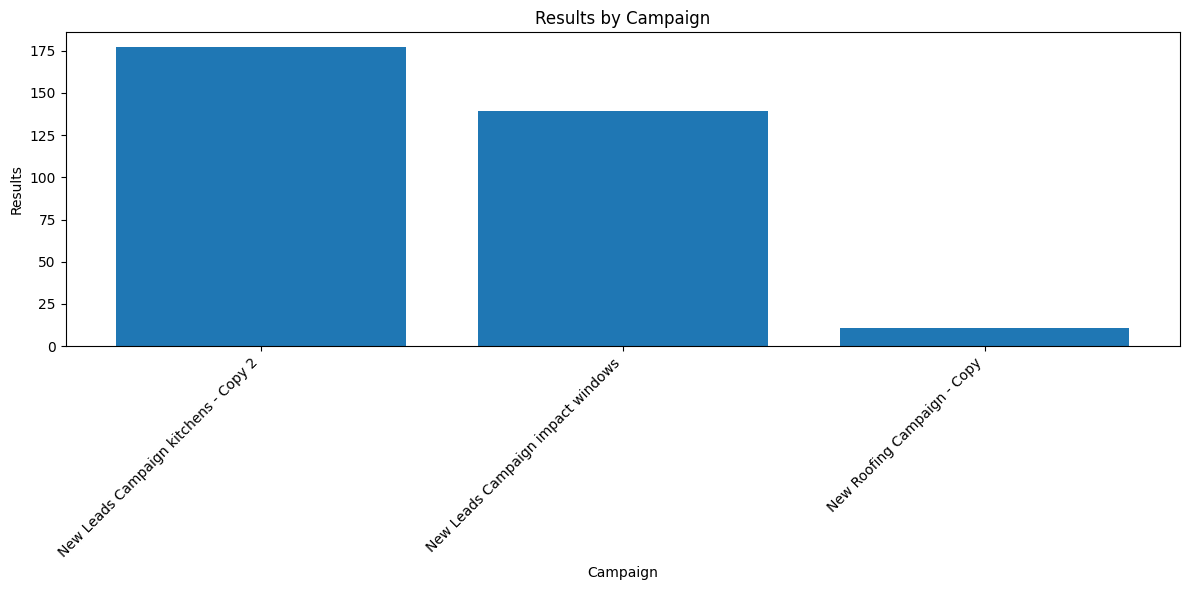

In [46]:
# RESULTS BY CAMPAIGN

plt.figure(figsize=(12,6))

plt.bar(
    top_campaigns['campaign_name'],
    top_campaigns['results']
)

plt.xticks(rotation=45, ha='right')

plt.title("Results by Campaign")
plt.xlabel("Campaign")
plt.ylabel("Results")

plt.tight_layout()
plt.savefig("C:/Users/Ilaya/Downloads/data/screenshots/results_by_campaign.png")
plt.show()

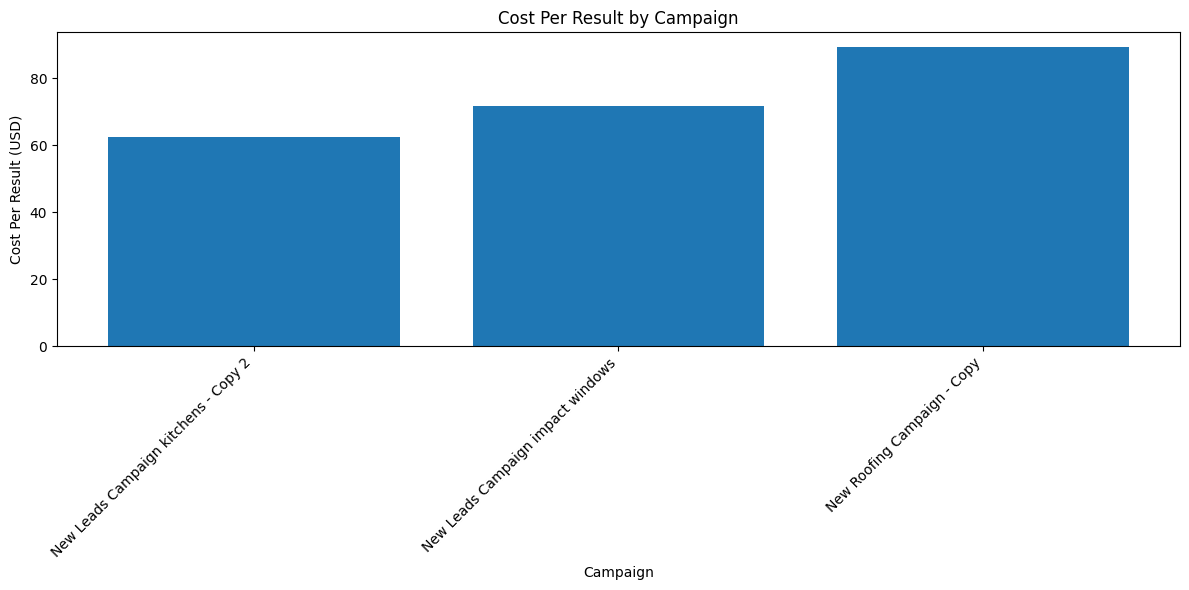

In [45]:
# COST PER RESULT

plt.figure(figsize=(12,6))

plt.bar(
    top_campaigns['campaign_name'],
    top_campaigns['cost_per_results']
)

plt.xticks(rotation=45, ha='right')

plt.title("Cost Per Result by Campaign")
plt.xlabel("Campaign")
plt.ylabel("Cost Per Result (USD)")

plt.tight_layout()
plt.savefig("C:/Users/Ilaya/Downloads/data/screenshots/cost_per_result_by_campaign.png")
plt.show()

In [31]:
# FUNNEL METRICS

total_contacts = len(contacts)
total_opportunities = len(opportunities)
total_results = campaigns['results'].sum()

print("Contacts:", total_contacts)
print("Results:", total_results)
print("Opportunities:", total_opportunities)

print("\nConversion Rates")

print(
    "Contact → Result:",
    round((total_results / total_contacts) * 100, 2),
    "%"
)

print(
    "Result → Opportunity:",
    round((total_opportunities / total_results) * 100, 2),
    "%"
)

print(
    "Contact → Opportunity:",
    round((total_opportunities / total_contacts) * 100, 2),
    "%"
)

Contacts: 1277
Results: 327.0
Opportunities: 192

Conversion Rates
Contact → Result: 25.61 %
Result → Opportunity: 58.72 %
Contact → Opportunity: 15.04 %


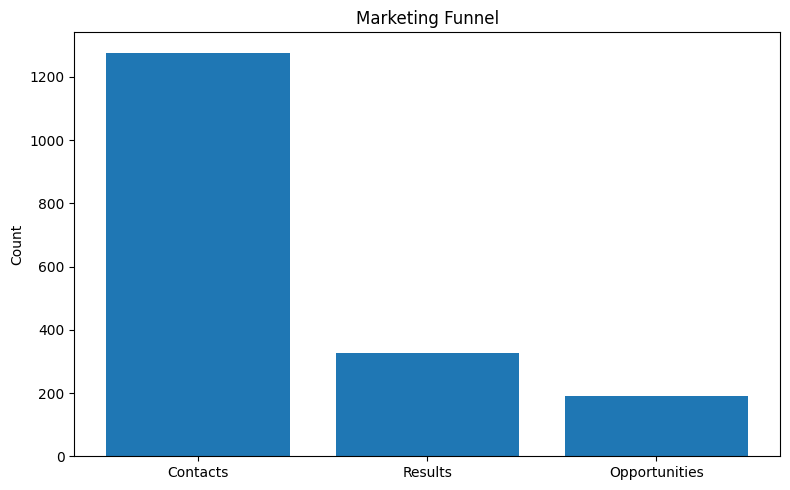

In [43]:
import matplotlib.pyplot as plt

# FUNNEL DATA

funnel_labels = [
    'Contacts',
    'Results',
    'Opportunities'
]

funnel_values = [
    total_contacts,
    total_results,
    total_opportunities
]

# FUNNEL CHART

plt.figure(figsize=(8,5))

plt.bar(
    funnel_labels,
    funnel_values
)

plt.title("Marketing Funnel")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("C:/Users/Ilaya/Downloads/data/screenshots/FUNNEL_DATA.png")
plt.show()

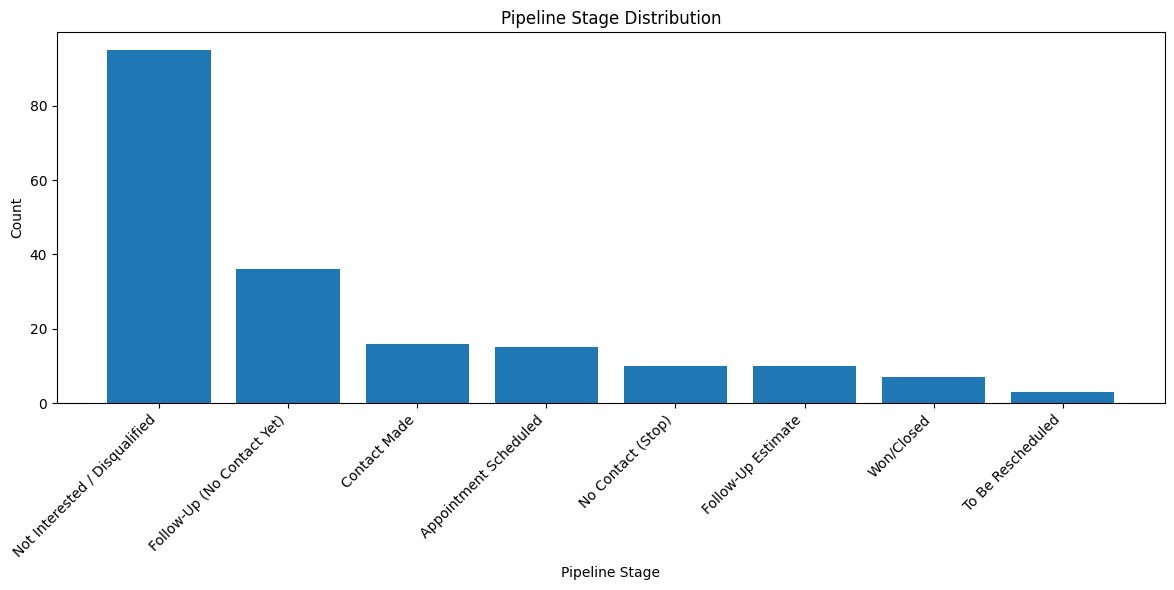

In [42]:
# PIPELINE STAGE ANALYSIS

stage_counts = opportunities['stage'].value_counts()

plt.figure(figsize=(12,6))

plt.bar(
    stage_counts.index,
    stage_counts.values
)

plt.xticks(rotation=45, ha='right')

plt.title("Pipeline Stage Distribution")
plt.xlabel("Pipeline Stage")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("C:/Users/Ilaya/Downloads/data/screenshots/PIPELINE_STAGE_ANALYSIS.png")
plt.show()

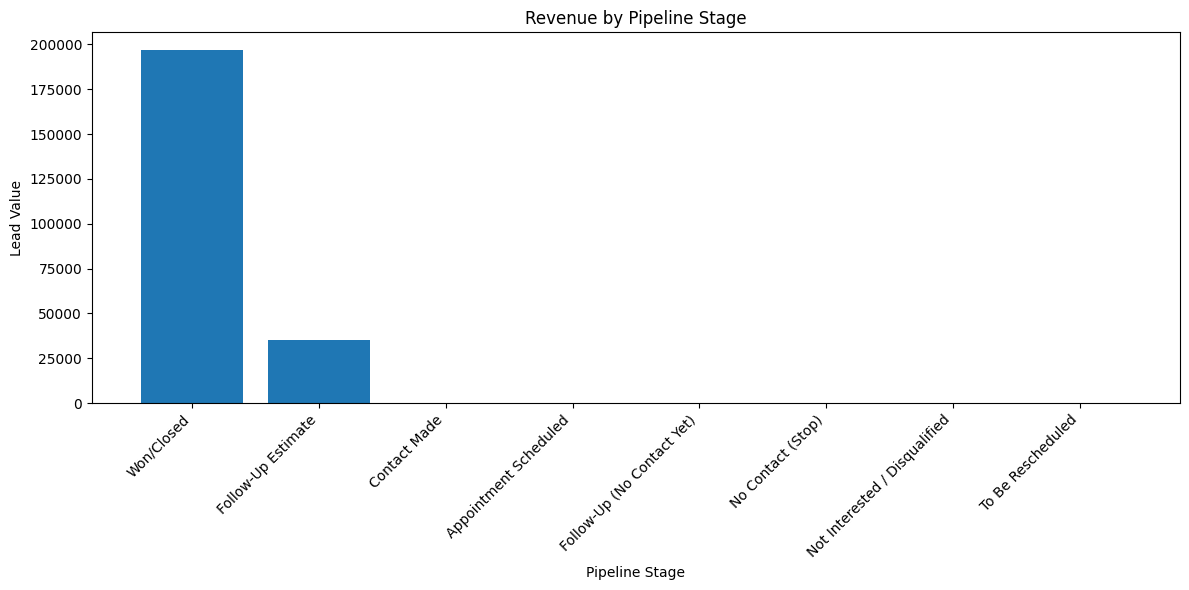

In [41]:
# REVENUE BY PIPELINE STAGE

stage_revenue = opportunities.groupby('stage')['lead_value'].sum()

stage_revenue = stage_revenue.sort_values(ascending=False)

plt.figure(figsize=(12,6))

plt.bar(
    stage_revenue.index,
    stage_revenue.values
)

plt.xticks(rotation=45, ha='right')

plt.title("Revenue by Pipeline Stage")
plt.xlabel("Pipeline Stage")
plt.ylabel("Lead Value")

plt.tight_layout()
plt.savefig("C:/Users/Ilaya/Downloads/data/screenshots/REVENUE_BY_PIPELINE_STAGE.png")
plt.show()

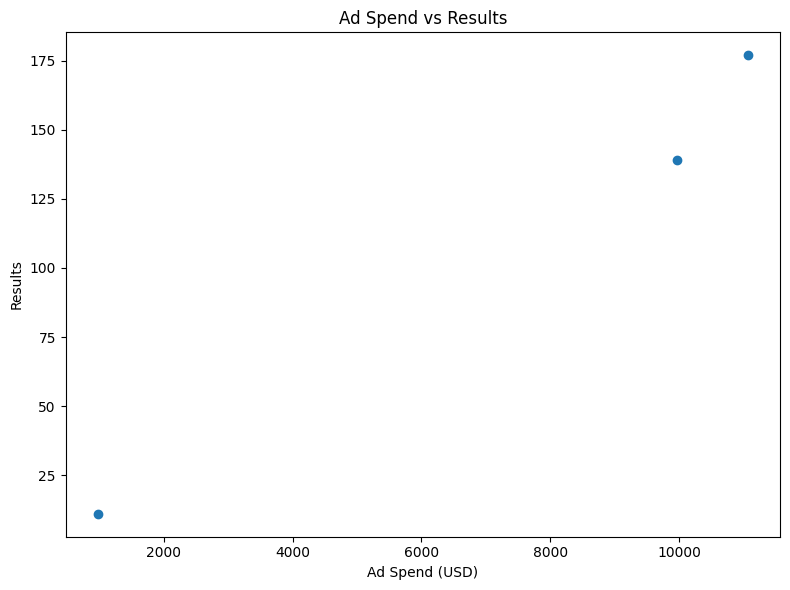

In [40]:

# SPEND VS RESULTS

plt.figure(figsize=(8,6))

plt.scatter(
    campaigns['amount_spent_(usd)'],
    campaigns['results']
)

plt.title("Ad Spend vs Results")
plt.xlabel("Ad Spend (USD)")
plt.ylabel("Results")

plt.tight_layout()
plt.savefig("C:/Users/Ilaya/Downloads/data/screenshots/Ad_Spend_vs_Results.png")
plt.show()

In [36]:
# CORRELATION MATRIX

numeric_columns = campaigns[[
    'amount_spent_(usd)',
    'results',
    'reach',
    'impressions',
    'link_clicks',
    'landing_page_views'
]]

correlation_matrix = numeric_columns.corr()

print(correlation_matrix)

                    amount_spent_(usd)   results     reach  impressions  \
amount_spent_(usd)            1.000000  0.992598  0.991920     0.997047   
results                       0.992598  1.000000  0.939849     0.999969   
reach                         0.991920  0.939849  1.000000     0.979413   
impressions                   0.997047  0.999969  0.979413     1.000000   
link_clicks                   0.904668  0.846223  0.977331     0.842008   
landing_page_views                 NaN       NaN       NaN          NaN   

                    link_clicks  landing_page_views  
amount_spent_(usd)     0.904668                 NaN  
results                0.846223                 NaN  
reach                  0.977331                 NaN  
impressions            0.842008                 NaN  
link_clicks            1.000000                 NaN  
landing_page_views          NaN                 NaN  


In [37]:
# KPI SUMMARY TABLE

kpi_summary = pd.DataFrame({
    'Metric': [
        'Total Contacts',
        'Total Opportunities',
        'Total Campaigns',
        'Total Ad Spend',
        'Total Results',
        'Cost Per Result',
        'Opportunity Rate (%)',
        'Total Lead Value',
        'Estimated ROAS'
    ],
    'Value': [
        total_contacts,
        total_opportunities,
        total_campaigns,
        round(total_spend, 2),
        total_results,
        round(cost_per_result, 2),
        round(opportunity_rate * 100, 2),
        round(total_lead_value, 2),
        round(estimated_roas, 2)
    ]
})

kpi_summary

,Metric,Value
0,Total Contacts,1277.00
1,Total Opportunities,192.00
2,Total Campaigns,18.00
3,Total Ad Spend,22019.11
4,Total Results,327.00
5,Cost Per Result,67.34
6,Opportunity Rate (%),15.04
7,Total Lead Value,231900.00
8,Estimated ROAS,10.53


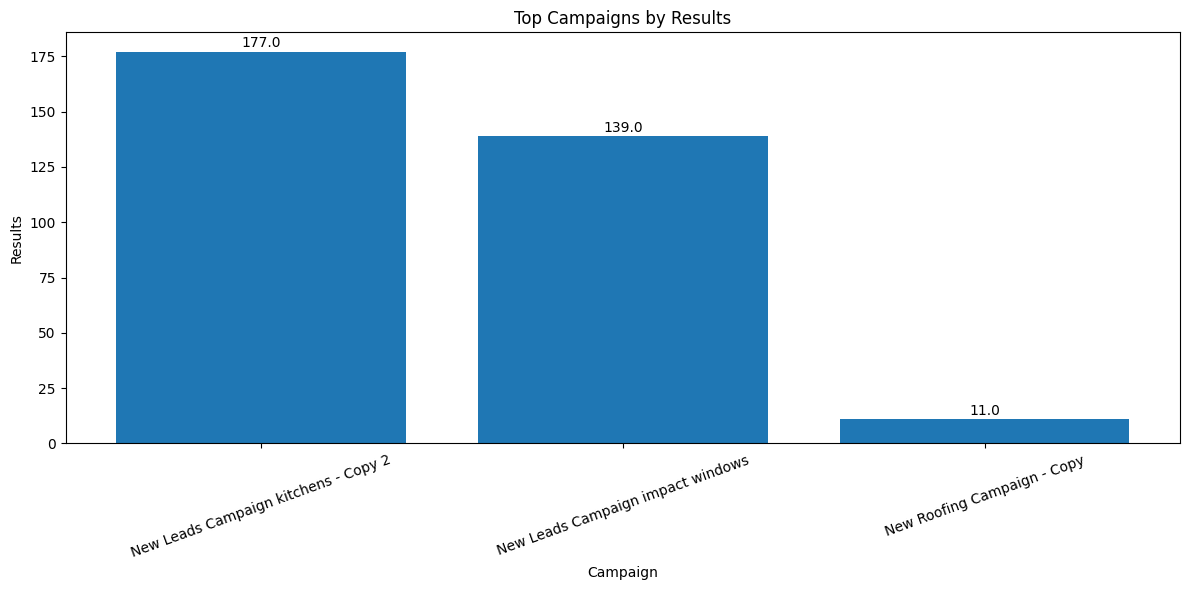

In [39]:
# TOP CAMPAIGNS BY RESULTS

top_results = campaign_performance.sort_values(
    by='results',
    ascending=False
).head(5)

plt.figure(figsize=(12,6))

bars = plt.bar(
    top_results['campaign_name'],
    top_results['results']
)

plt.title("Top Campaigns by Results")
plt.xlabel("Campaign")
plt.ylabel("Results")

plt.xticks(rotation=20)

# add values on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 2,
        round(yval, 1),
        ha='center'
    )

plt.tight_layout()
plt.savefig("C:/Users/Ilaya/Downloads/data/screenshots/top_campaigns_results.png")
plt.show()